<a href="https://colab.research.google.com/github/medwithrish-dot/internity/blob/main/stockproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

In [ ]:
# Import core libraries
import pandas as pd # for working w the data tabes
import matplotlib.pyplot as plt # for makign graphs
import yfinance as yf # for dw stock price data

In [ ]:
# dw Apple(aapl) stock data for the last 10 yrs
apple = yf.download('AAPL', period='10y')

# display the first 5 rows of the Dataframe
apple.head()

/tmp/ipython-input-625012633.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-08-24,23.173702,24.450144,20.674753,21.319716,648825200
2015-08-25,23.313036,24.969264,23.259102,24.969264,414406400
2015-08-26,24.650152,24.695097,23.607426,24.065864,387098400
2015-08-27,25.376009,25.447921,24.724305,25.220950,338464400
2015-08-28,25.459160,25.463654,25.065890,25.207467,212657600


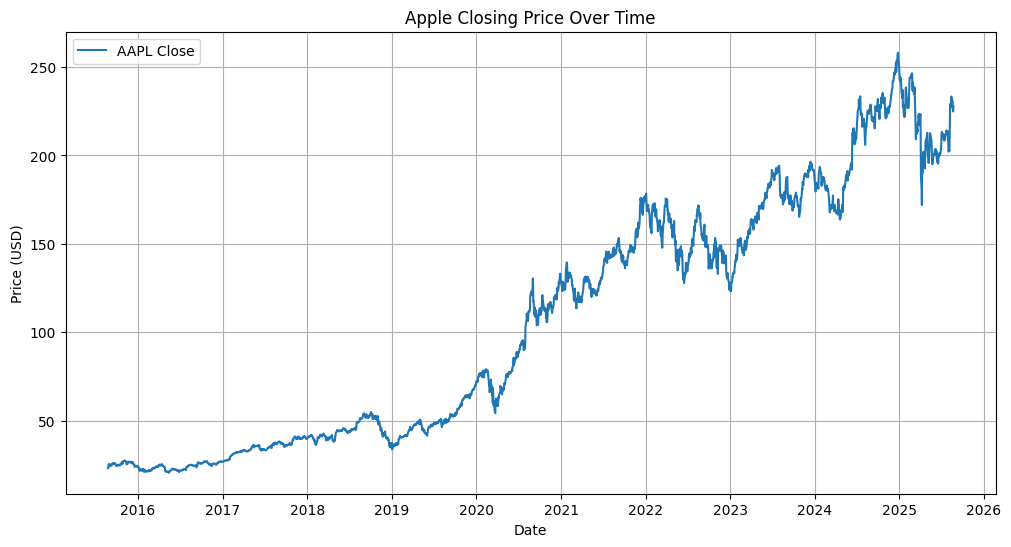

In [ ]:
# plot apple's closing price over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='AAPL Close') # draws line chart of daily closing prices
plt.title('Apple Closing Price Over Time') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

In [ ]:
# calc daily returns as % change
apple['Daily Return'] = apple['Close'].pct_change()

# show first 5 rows
apple.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2015-08-24,23.173702,24.450144,20.674753,21.319716,648825200,NaN
2015-08-25,23.313036,24.969264,23.259102,24.969264,414406400,0.006013
2015-08-26,24.650152,24.695097,23.607426,24.065864,387098400,0.057355
2015-08-27,25.376009,25.447921,24.724305,25.220950,338464400,0.029446
2015-08-28,25.459160,25.463654,25.065890,25.207467,212657600,0.003277


In [ ]:
apple.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

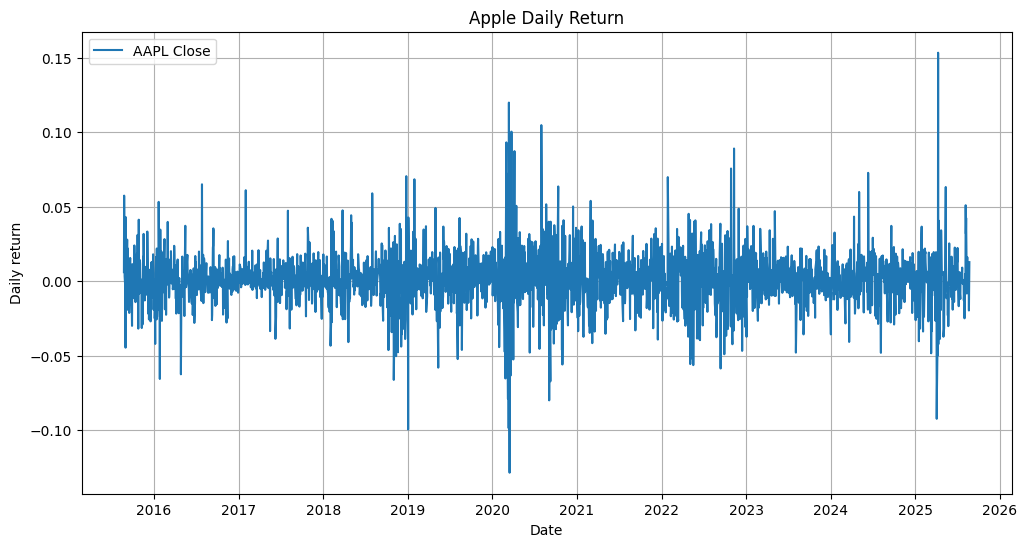

In [ ]:
# plot daily returns over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Daily Return'], label='AAPL Close') # draws line chart of daily returns
plt.title('Apple Daily Return') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Daily return') # y-axis label
plt.legend() # show legend
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

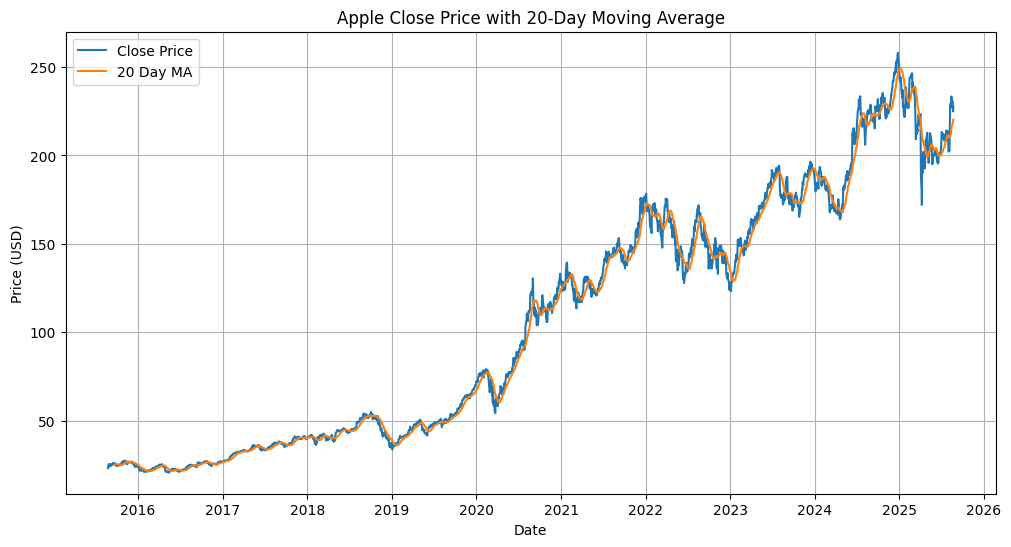

In [ ]:
# calculate 20 day moving avg of closing price
apple['20 Day MA'] = apple['Close'].rolling(window=20).mean()

# plot the closing price and 20 day moving avg

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='Close Price') # actual close price
plt.plot(apple['20 Day MA'], label='20 Day MA') # 20 day moving avg
plt.title('Apple Close Price with 20-Day Moving Average') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

In [ ]:
# dw jp morgan (jpm) stock data for last 10 yrs
import yfinance as yf

jpm = yf.download('JPM', period='10y')

# keep only the 'close' coloumn for prediction
jpm_close = jpm[['Close']]

/tmp/ipython-input-3746366711.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# normalise data for LSTM (values between 0 and 1)
from sklearn.preprocessing import MinMaxScaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm = MinMaxScaler(feature_range=(0,1))

# scale apple and jpm closing prices
apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled = scaler_jpm.fit_transform(jpm_close)

In [ ]:
import numpy as np

# function to create sequences for LSTM
def create_sequences(data, seq_length=60):
  X, y = [], []
  for i in range(seq_length, len(data)):
    X.append(data[i-seq_length:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

# apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# jp  morgan sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# reshape to 3d for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

def build_lstm():
  model = Sequential()
  model.add(Input(shape=(60,1)))
  model.add(LSTM(units=50, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

# build models for apple and jpm
model_apple = build_lstm()
model_jpm = build_lstm()

In [ ]:

# train apple lstm
model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)

# train jpm lstm
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0411
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0024
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0023
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0024
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0021
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.0302
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0018
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0013
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0013
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0013


In [ ]:
# predict
pred_apple = model_apple.predict(X_apple)
pred_jpm = model_jpm.predict(X_jpm)

# inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm = scaler_jpm.inverse_transform(pred_jpm)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


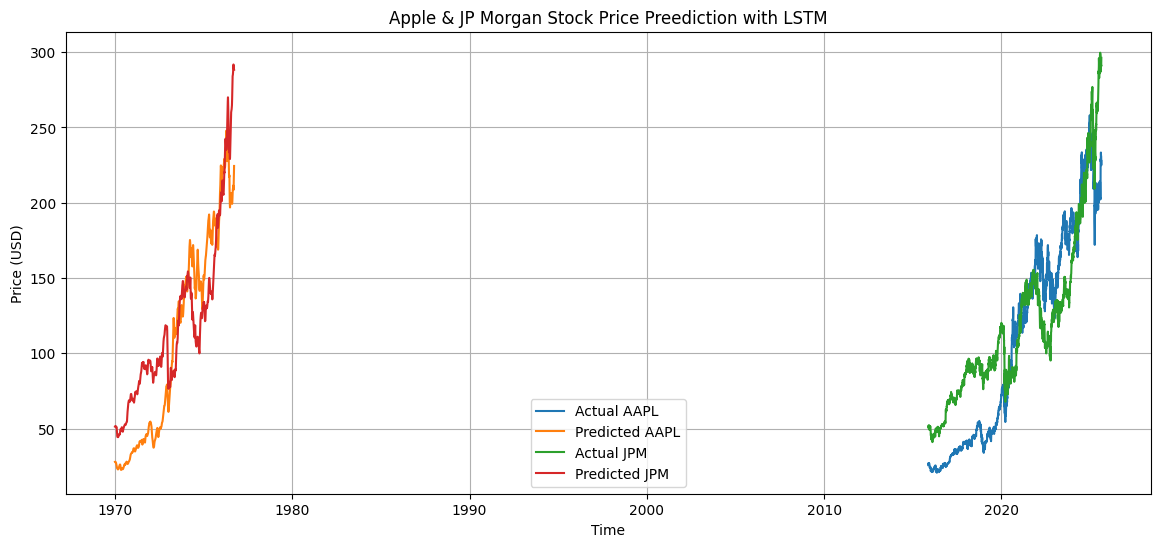

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# apple actual vs predicted
plt.plot(apple['Close'][60:], label='Actual AAPL')
plt.plot(pred_apple, label='Predicted AAPL')

# jpm actual vs predicted
plt.plot(jpm['Close'][60:], label='Actual JPM')
plt.plot(pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Preediction with LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)  # make it 2D for the scaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaled_data_apple = scaler_apple.fit_transform(dataset)

In [ ]:
dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

scaler_jpm = MinMaxScaler(feature_range=(0,1))
scaled_data_jpm = scaler_jpm.fit_transform(dataset)

In [ ]:
X_test_apple = []
y_test_apple = []

for i in range(60, len(scaled_data_apple)):
    X_test_apple.append(scaled_data_apple[i-60:i, 0])
    y_test_apple.append(scaled_data_apple[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

In [ ]:
X_test_jpm = []
y_test_jpm = []

for i in range(60, len(scaled_data_jpm)):
    X_test_jpm.append(scaled_data_jpm[i-60:i, 0])
    y_test_jpm.append(scaled_data_jpm[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

In [ ]:
dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)

# Split into training and test sets
train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]  # include last 60 for sequences

# Create X_test and y_test
X_test_apple = []
y_test_apple = []

for i in range(60, len(test_data)):
    X_test_apple.append(test_data[i-60:i, 0])
    y_test_apple.append(test_data[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

In [ ]:
dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(test_data)):
    X_test_jpm.append(test_data[i-60:i, 0])
    y_test_jpm.append(test_data[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

In [ ]:
# Predict on test data
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_jpm   = model_jpm.predict(X_test_jpm)

# If you scaled the data, inverse-transform to get actual prices
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

y_pred_jpm = scaler_jpm.inverse_transform(y_pred_jpm)
y_test_jpm = scaler_jpm.inverse_transform(y_test_jpm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


ValueError: Expected 2D array, got 1D array instead:
array=[175.51087952 179.36315918 174.66914368 176.87750244 178.44216919
 182.33401489 185.82980347 186.04769897 187.62225342 187.85993958
 181.13577271 175.837677   176.45166016 177.620224   174.58990479
 172.52017212 174.03533936 173.31240845 176.24371338 177.33302307
 173.7877655  172.24287415 173.09454346 174.37202454 170.29200745
 168.77684021 169.03431702 169.54927063 172.06463623 170.72772217
 171.97550964 173.21337891 175.76835632 177.25379944 176.65963745
 178.05595398 178.95716858 177.11517334 176.98640442 175.43164062
 174.13435364 173.7580719  171.20309448 171.32189941 171.75764465
 169.44035339 165.2711792  166.58827209 168.63819885 169.11355591
 172.28251648 175.84759521 174.93652344 177.4914856  180.05636597
 181.11599731 180.64064026 184.83512878 183.24858093 185.8664093
 186.43157959 188.11734009 188.0974884  189.8427124  189.039505
 189.7039032  188.37516785 188.19665527 188.80154419 187.78018188
 188.35531616 189.63

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd # for working w the data tabes
import matplotlib.pyplot as plt # for makign graphs
import yfinance as yf # for dw stock price data

# dw Apple(aapl) stock data for the last 10 yrs
apple = yf.download('AAPL', period='10y')

# display the first 5 rows of the Dataframe
apple.head()

# plot apple's closing price over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='AAPL Close') # draws line chart of daily closing prices
plt.title('Apple Closing Price Over Time') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# calc daily returns as % change
apple['Daily Return'] = apple['Close'].pct_change()

# show first 5 rows
apple.head()

# plot daily returns over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Daily Return'], label='AAPL Close') # draws line chart of daily returns
plt.title('Apple Daily Return') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Daily return') # y-axis label
plt.legend() # show legend
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# calculate 20 day moving avg of closing price
apple['20 Day MA'] = apple['Close'].rolling(window=20).mean()

# plot the closing price and 20 day moving avg

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='Close Price') # actual close price
plt.plot(apple['20 Day MA'], label='20 Day MA') # 20 day moving avg
plt.title('Apple Close Price with 20-Day Moving Average') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# dw jp morgan (jpm) stock data for last 10 yrs
import yfinance as yf

jpm = yf.download('JPM', period='10y')

# keep only the 'close' coloumn for prediction
jpm_close = jpm[['Close']]

# normalise data for LSTM (values between 0 and 1)
from sklearn.preprocessing import MinMaxScaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm = MinMaxScaler(feature_range=(0,1))

# scale apple and jpm closing prices
apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled = scaler_jpm.fit_transform(jpm_close)

import numpy as np

# function to create sequences for LSTM
def create_sequences(data, seq_length=60):
  X, y = [], []
  for i in range(seq_length, len(data)):
    X.append(data[i-seq_length:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

# apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# jp  morgan sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# reshape to 3d for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

def build_lstm():
  model = Sequential()
  model.add(Input(shape=(60,1)))
  model.add(LSTM(units=50, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

# build models for apple and jpm
model_apple = build_lstm()
model_jpm = build_lstm()

# train apple lstm
model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)

# train jpm lstm
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# predict
pred_apple = model_apple.predict(X_apple)
pred_jpm = model_jpm.predict(X_jpm)

# inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm = scaler_jpm.inverse_transform(pred_jpm)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# apple actual vs predicted
plt.plot(apple['Close'][60:], label='Actual AAPL')
plt.plot(pred_apple, label='Predicted AAPL')

# jpm actual vs predicted
plt.plot(jpm['Close'][60:], label='Actual JPM')
plt.plot(pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Preediction with LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.preprocessing import MinMaxScaler
import numpy as np

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)  # make it 2D for the scaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaled_data_apple = scaler_apple.fit_transform(dataset)

dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

scaler_jpm = MinMaxScaler(feature_range=(0,1))
scaled_data_jpm = scaler_jpm.fit_transform(dataset)

X_test_apple = []
y_test_apple = []

for i in range(60, len(scaled_data_apple)):
    X_test_apple.append(scaled_data_apple[i-60:i, 0])
    y_test_apple.append(scaled_data_apple[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(scaled_data_jpm)):
    X_test_jpm.append(scaled_data_jpm[i-60:i, 0])
    y_test_jpm.append(scaled_data_jpm[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)

# Split into training and test sets
train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]  # include last 60 for sequences

# Create X_test and y_test
X_test_apple = []
y_test_apple = []

for i in range(60, len(test_data)):
    X_test_apple.append(test_data[i-60:i, 0])
    y_test_apple.append(test_data[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(test_data)):
    X_test_jpm.append(test_data[i-60:i, 0])
    y_test_jpm.append(test_data[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

# Predict on test data
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_jpm   = model_jpm.predict(X_test_jpm)

# If you scaled the data, inverse-transform to get actual prices
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

y_pred_jpm = scaler_jpm.inverse_transform(y_pred_jpm)
y_test_jpm = scaler_jpm.inverse_transform(y_test_jpm)

/tmp/ipython-input-3934754315.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3934754315.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm   = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0614
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0028
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0027
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0021
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0023
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0179
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0019
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0017
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0016
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0015
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


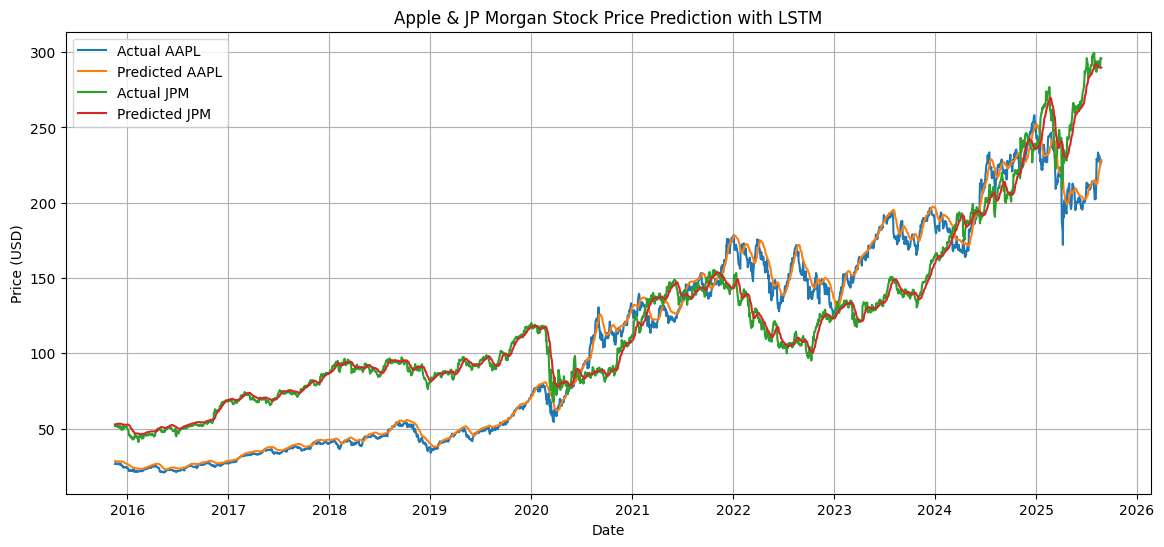

RMSE Apple: 5.45
RMSE JPM: 4.80


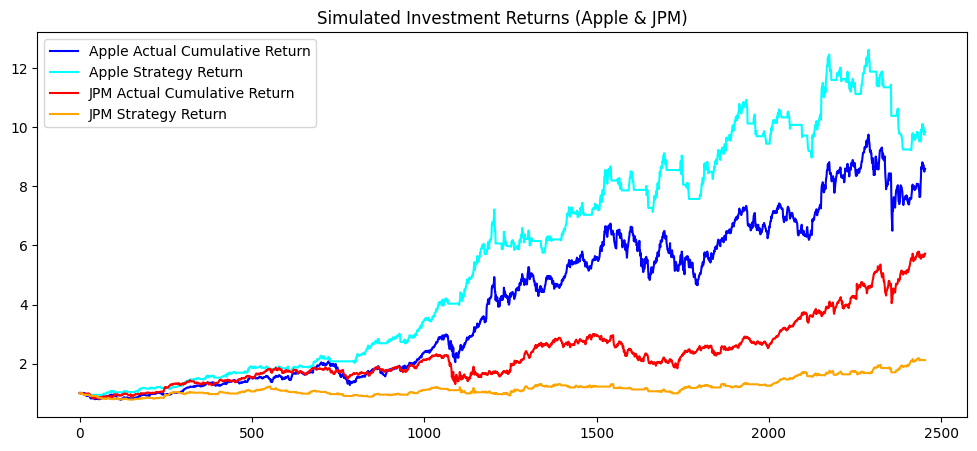

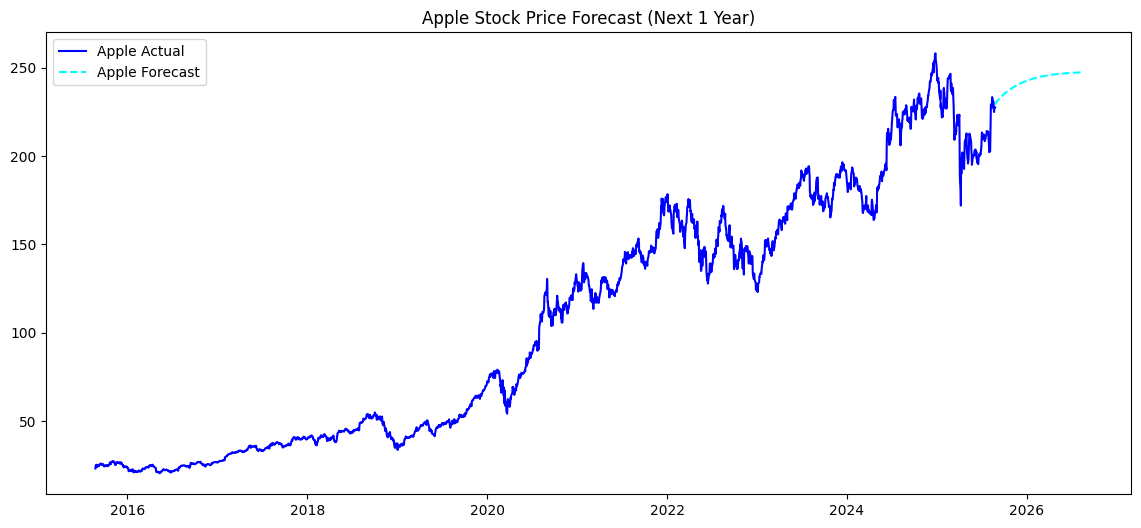

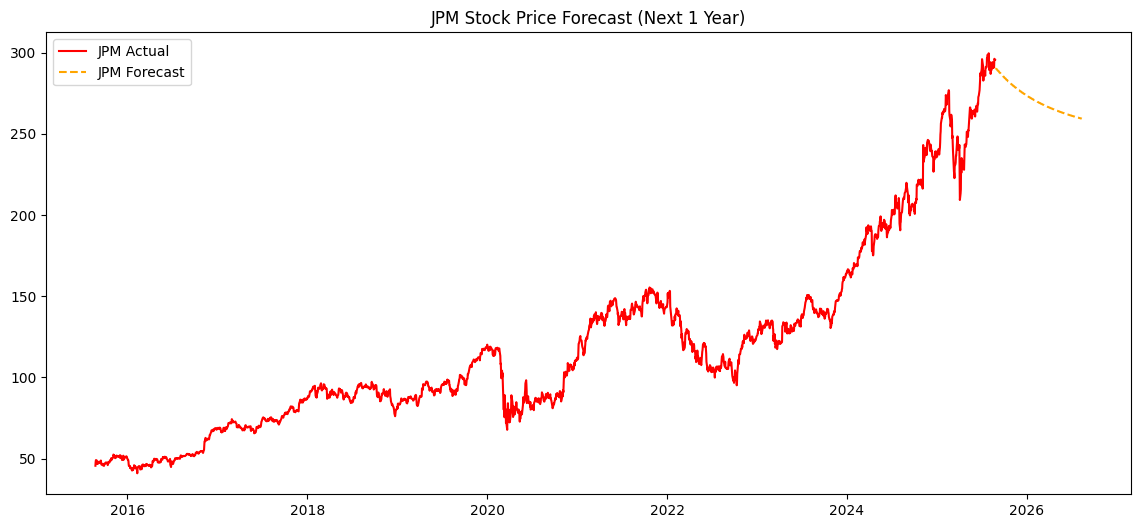

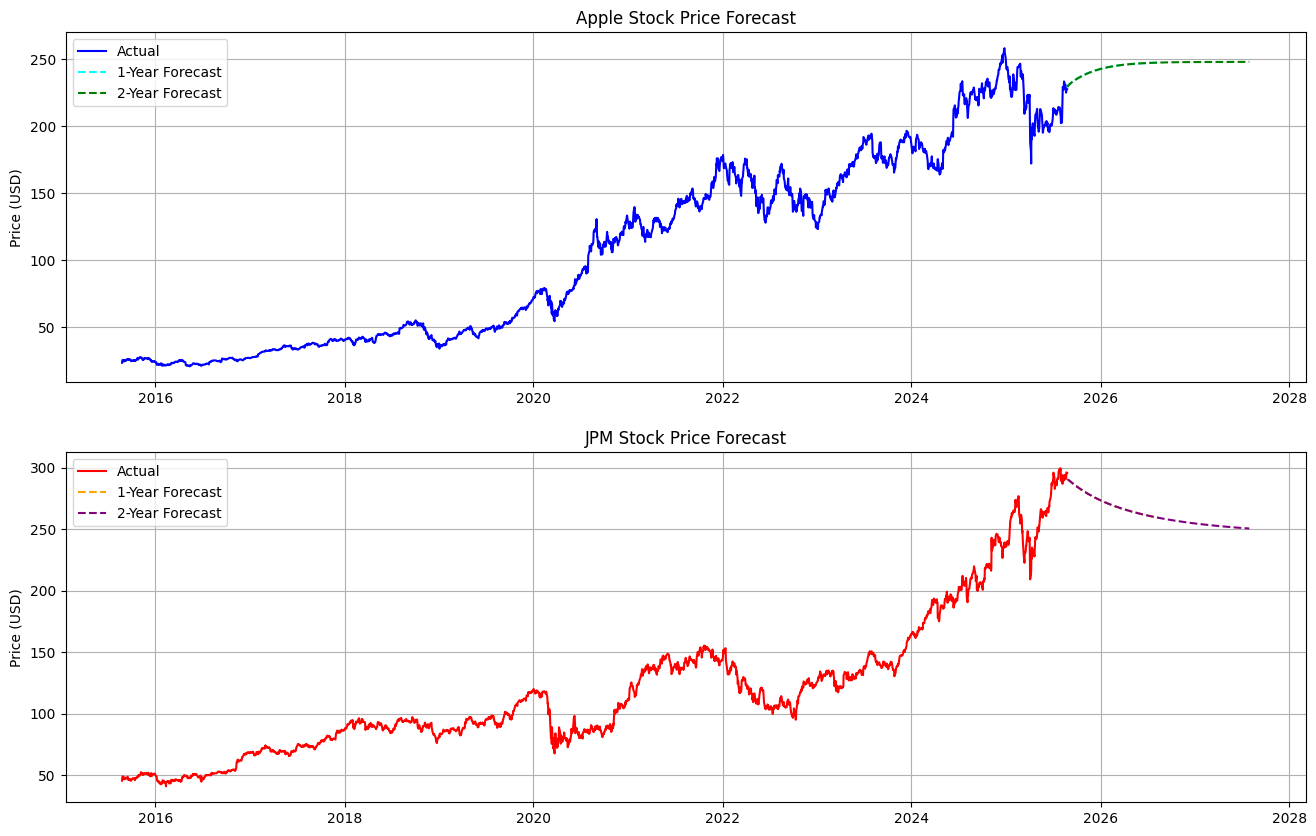

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates instead of row index
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))

# Apple actual vs predicted
plt.plot(dates_apple, apple['Close'][60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')

# JPM actual vs predicted
plt.plot(dates_jpm, jpm['Close'][60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy (RMSE)

from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'][60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'][60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns

def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []

    for i in range(len(daily_returns)):
        # simple strategy: buy if predicted price increases from previous day
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)

    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'][60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'][60:].values, pred_jpm)

# Plot simulated returns
plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 year into the future (~252 trading days)

def forecast_future(model, last_60_scaled, scaler, steps=252):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))

    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)

    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# get last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

future_apple = forecast_future(model_apple, last_60_apple, scaler_apple)
future_jpm   = forecast_future(model_jpm, last_60_jpm, scaler_jpm)

# create future dates
import pandas as pd
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_jpm   = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')


# Plot future forecast

plt.figure(figsize=(14,6))
plt.plot(apple.index, apple['Close'], label='Apple Actual', color='blue')
plt.plot(future_dates_apple, future_apple, label='Apple Forecast', color='cyan', linestyle='--')
plt.legend()
plt.title('Apple Stock Price Forecast (Next 1 Year)')
plt.show()

plt.figure(figsize=(14,6))
plt.plot(jpm.index, jpm['Close'], label='JPM Actual', color='red')
plt.plot(future_dates_jpm, future_jpm, label='JPM Forecast', color='orange', linestyle='--')
plt.legend()
plt.title('JPM Stock Price Forecast (Next 1 Year)')
plt.show()


# Forecast 1 & 2 years ahead

def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates

last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting

fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()

/tmp/ipython-input-114157768.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-114157768.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm   = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0378
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0030
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0024
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0021
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0017
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.0269
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0018
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0016
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0016
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0014
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Apple RMSE: 5.85, MAPE: 127.50%
JPM RMSE: 7.22, MAPE: 60.03%


KeyError: 60

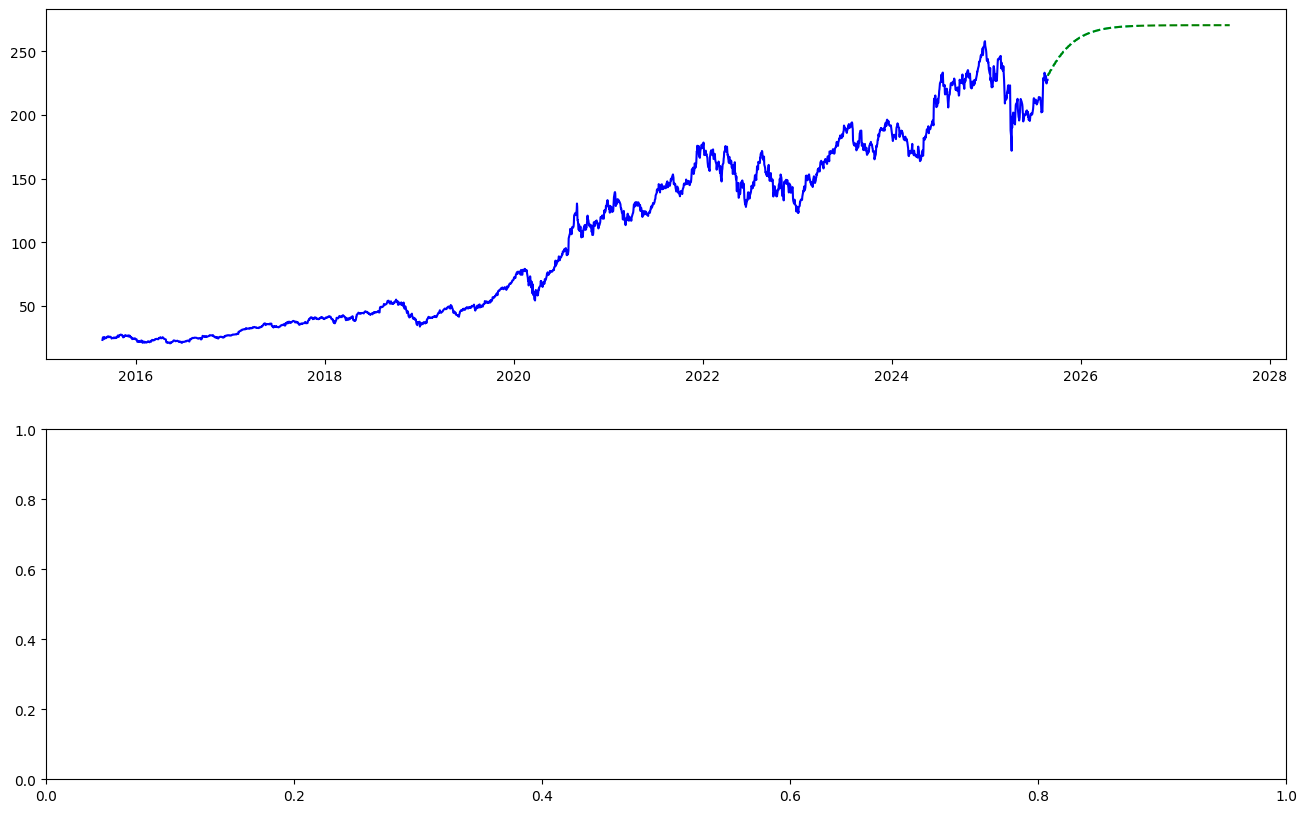

In [ ]:
# Install yfinance
!pip install yfinance --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (last 10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_apple, y_apple = create_sequences(apple_scaled)
X_jpm, y_jpm     = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model function
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict on training data
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

# Performance metrics
pred_apple_flat = pred_apple.flatten()
pred_jpm_flat   = pred_jpm.flatten()

rmse_apple = math.sqrt(mean_squared_error(apple['Close'][60:], pred_apple_flat))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'][60:], pred_jpm_flat))

mape_apple = np.mean(np.abs((apple['Close'][60:].values - pred_apple_flat) / apple['Close'][60:].values)) * 100
mape_jpm   = np.mean(np.abs((jpm['Close'][60:].values - pred_jpm_flat) / jpm['Close'][60:].values)) * 100

print(f"Apple RMSE: {rmse_apple:.2f}, MAPE: {mape_apple:.2f}%")
print(f"JPM RMSE: {rmse_jpm:.2f}, MAPE: {mape_jpm:.2f}%")

# Simulated returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'][60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'][60:].values, pred_jpm)

# Forecast future prices
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# Forecast 1-year & 2-year (252 trading days per year)
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, 252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, 504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, 252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, 504)

# Future dates
future_dates_1y_apple = pd.date_range(apple.index[-1] + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(apple.index[-1] + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(jpm.index[-1] + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(jpm.index[-1] + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].plot(dates_apple[1:], cum_strategy_apple * apple['Close'][60], label='Strategy Cumulative', color='orange', alpha=0.6)
axs[0].set_title('Apple Stock Price & Strategy Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].plot(dates_jpm[1:], cum_strategy_jpm * jpm['Close'][60], label='Strategy Cumulative', color='cyan', alpha=0.6)
axs[1].set_title('JPM Stock Price & Strategy Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

/tmp/ipython-input-3682460051.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3682460051.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm   = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 0.0432
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0035
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0026
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0024
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0021
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0212
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0017
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0012
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0014
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0012
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


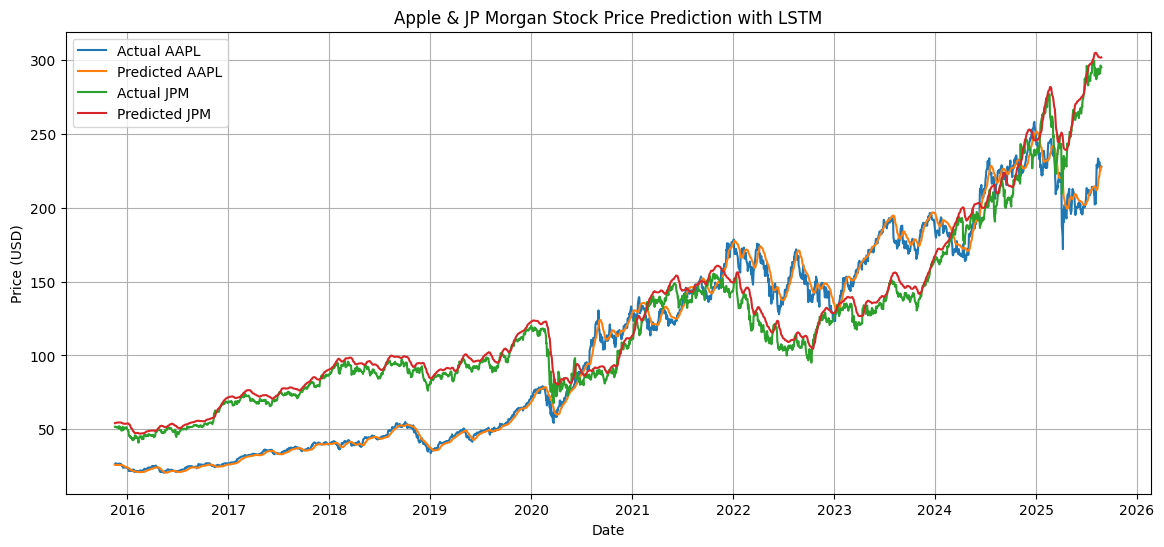

RMSE Apple: 5.14
RMSE JPM: 6.92


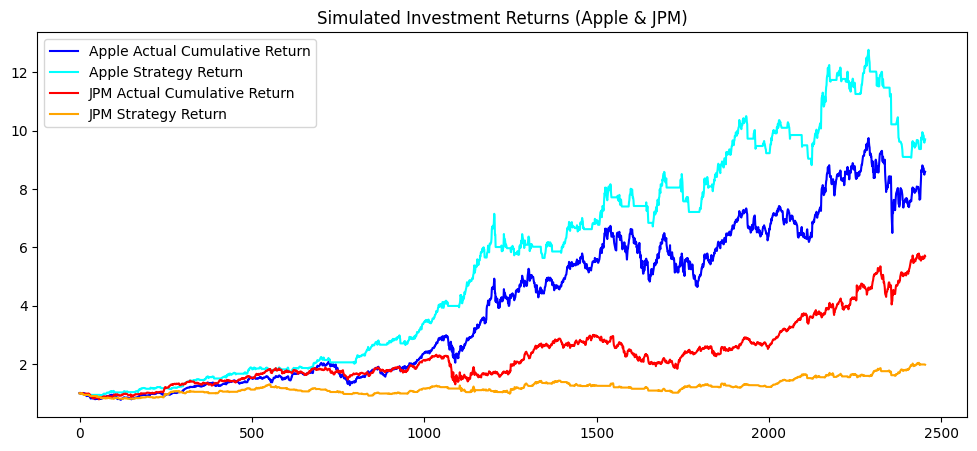

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 & 2 years into the future (~252 trading days per year)
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting of actual vs 1 & 2 year forecasts
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()

/tmp/ipython-input-2640096507.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2640096507.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm   = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0471
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0026
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0026
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0027
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0020
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0221
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0016
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0017
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0013
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0016
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


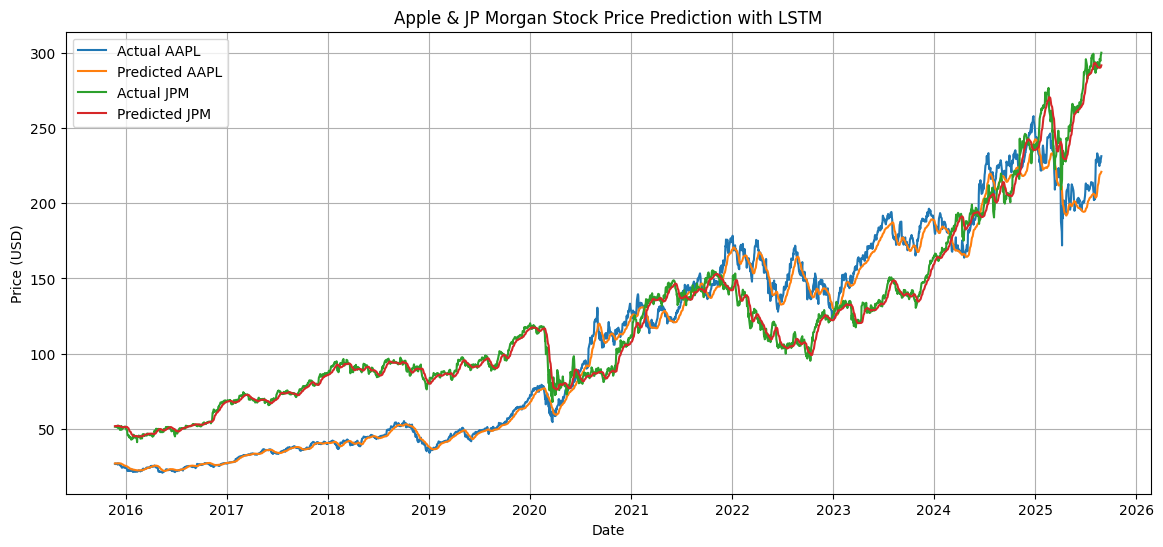

RMSE Apple: 5.93
RMSE JPM: 4.73


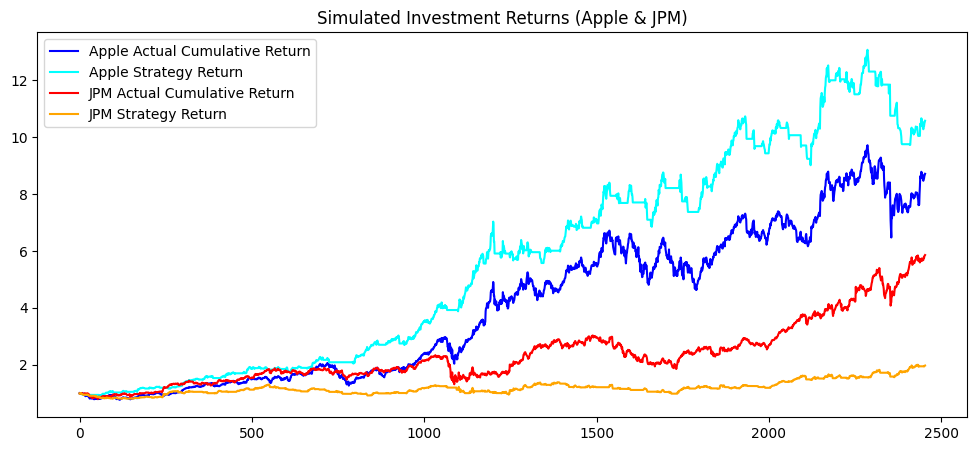

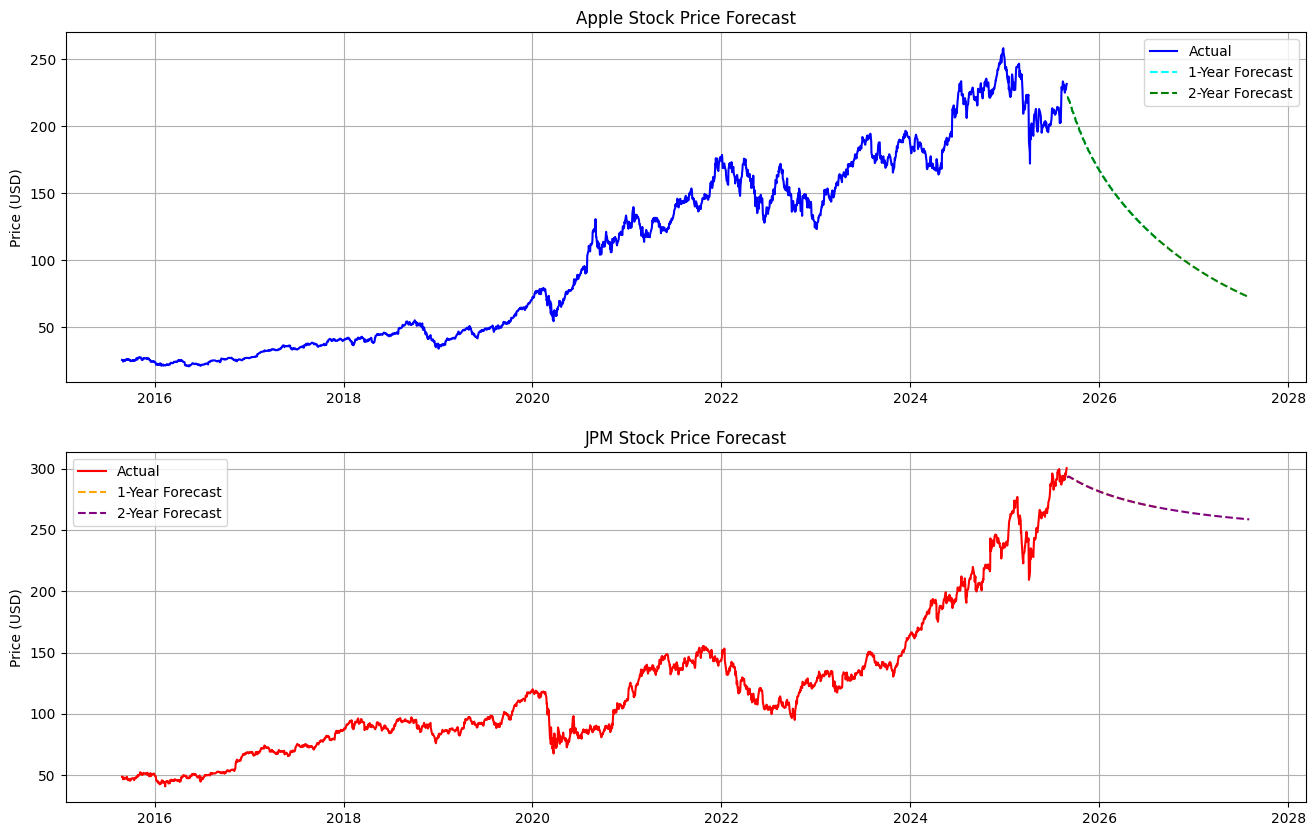

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 & 2 years into the future (~252 trading days per year)
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting of actual vs 1 & 2 year forecasts
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()